# 2D Try-On Experiments

Run the current lightweight system end to end on a local image: face analysis, segmentation, recommendation, and a few try-on renders.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from app.core.asset_bank import asset_bank_summary
from app.core.face_analyzer import analyze_face_image
from app.core.hair_segmentation import predict_hair_mask_image, save_predicted_hair_mask
from app.core.recommender import recommend_hairstyles
from app.core.tryon_2d_engine import render_static_tryon
from app.models.schemas import FaceAttributes, RecommendationPreferences

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
import importlib
import app.core.tryon_2d_engine as tryon_2d_engine

importlib.reload(tryon_2d_engine)
from app.core.tryon_2d_engine import render_static_tryon, render_static_tryon_image

print("Default renderer:", render_static_tryon.__name__)

Default renderer: render_legacy_static_tryon


In [3]:
INPUT_IMAGE_PATH = PROJECT_ROOT / 'backend' / 'outputs' / 'uploads' / '3c051efb9ea4468ab2c46dd7123dff11.jpg'
TARGET_GENDER = 'male'
TOP_K = 5
TRYON_TOP_K = 3

INPUT_IMAGE_PATH

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/outputs/uploads/3c051efb9ea4468ab2c46dd7123dff11.jpg')

In [4]:
bank = asset_bank_summary()
print('Active asset bank:', bank['metadata_dir'])
print('Asset count:', bank['asset_count'])
bank

Active asset bank: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\processed\celeba_full_hair_assets\reviewed_render_safe\kept_assets.jsonl
Asset count: 83


{'asset_count': 83,
 'metadata_dir': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_full_hair_assets\\reviewed_render_safe\\kept_assets.jsonl'}

In [5]:
if not INPUT_IMAGE_PATH.exists():
    raise FileNotFoundError(f'Image not found: {INPUT_IMAGE_PATH}')

analysis = analyze_face_image(INPUT_IMAGE_PATH)
print('Face detected:', analysis.face_detected)
print('Message:', analysis.message)
analysis.geometry, analysis.face_attributes

Face detected: True
Message: Face landmarks detected successfully.


({'face_width_px': 235.42,
  'face_height_px': 285.15,
  'forehead_width_px': 229.71,
  'cheekbone_width_px': 234.94,
  'jaw_width_px': 214.91,
  'chin_width_px': 170.87,
  'aspect_ratio': 1.2112,
  'forehead_to_jaw_ratio': 1.0689,
  'cheekbone_to_jaw_ratio': 1.0932,
  'chin_to_jaw_ratio': 0.7951},
 {'face_shape': 'oval',
  'forehead': 'medium',
  'jaw': 'medium',
  'cheekbone': 'medium',
  'face_width': 'narrow'})

In [6]:
with Image.open(INPUT_IMAGE_PATH) as source_image:
    subject_hair_mask = predict_hair_mask_image(source_image)

mask_path = save_predicted_hair_mask(subject_hair_mask, INPUT_IMAGE_PATH.stem)
print('Saved mask to:', mask_path)
mask_path

Saved mask to: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\predictions\hair_masks\3c051efb9ea4468ab2c46dd7123dff11_hair_mask.png


WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/outputs/predictions/hair_masks/3c051efb9ea4468ab2c46dd7123dff11_hair_mask.png')

In [7]:
preferences = RecommendationPreferences(
    allow_bangs=True,
    target_gender=TARGET_GENDER,
)
face_attrs = FaceAttributes(**analysis.face_attributes)
recommendation_response = recommend_hairstyles(face_attrs, preferences=preferences, top_k=TOP_K)
recommendation_rows = [
    {
        'asset_id': item.asset_id,
        'score': item.score,
        'gender_suitability': item.gender_suitability,
        'length': item.normalized_attributes.length,
        'curl': item.normalized_attributes.curl,
        'style_family': item.normalized_attributes.style_family,
        'reason': item.reason,
        'image_path': item.image_path,
    }
    for item in recommendation_response.recommendations
]
recommendation_df = pd.DataFrame(recommendation_rows)
recommendation_df

,asset_id,score,gender_suitability,length,curl,style_family,reason,image_path
0,celeba_full_hair_000064,0.960,male,medium,straight,pompadour,pompadour works well with balanced facial prop...,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000084,0.945,male,medium,straight,pompadour,pompadour works well with balanced facial prop...,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000158,0.930,male,medium,straight,pompadour,pompadour works well with balanced facial prop...,D:\Projects\Personal Projects\Hairstyle Recomm...
3,celeba_full_hair_000040,0.877,male,medium,straight,pompadour,pompadour works well with balanced facial prop...,D:\Projects\Personal Projects\Hairstyle Recomm...
4,celeba_full_hair_000082,0.824,male,medium,wavy,pompadour,pompadour works well with balanced facial prop...,D:\Projects\Personal Projects\Hairstyle Recomm...


In [8]:
tryon_rows = []
for item in recommendation_response.recommendations[:TRYON_TOP_K]:
    from app.core.asset_bank import get_asset_by_id
    asset = get_asset_by_id(item.asset_id)
    if asset is None:
        continue
    output_path = render_static_tryon(
        INPUT_IMAGE_PATH,
        analysis,
        asset,
        subject_hair_mask=subject_hair_mask,
    )
    tryon_rows.append(
        {
            'asset_id': item.asset_id,
            'score': item.score,
            'style_family': item.normalized_attributes.style_family,
            'output_path': output_path,
        }
    )

tryon_df = pd.DataFrame(tryon_rows)
tryon_df

,asset_id,score,style_family,output_path
0,celeba_full_hair_000064,0.960,pompadour,D:\Projects\Personal Projects\Hairstyle Recomm...
1,celeba_full_hair_000084,0.945,pompadour,D:\Projects\Personal Projects\Hairstyle Recomm...
2,celeba_full_hair_000158,0.930,pompadour,D:\Projects\Personal Projects\Hairstyle Recomm...


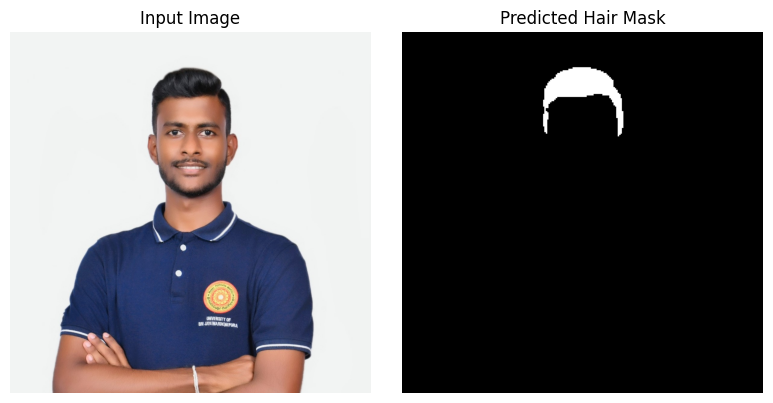

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
with Image.open(INPUT_IMAGE_PATH) as input_image:
    axes[0].imshow(input_image.convert('RGB'))
axes[0].set_title('Input Image')
axes[0].axis('off')
axes[1].imshow(subject_hair_mask, cmap='gray')
axes[1].set_title('Predicted Hair Mask')
axes[1].axis('off')
plt.tight_layout()

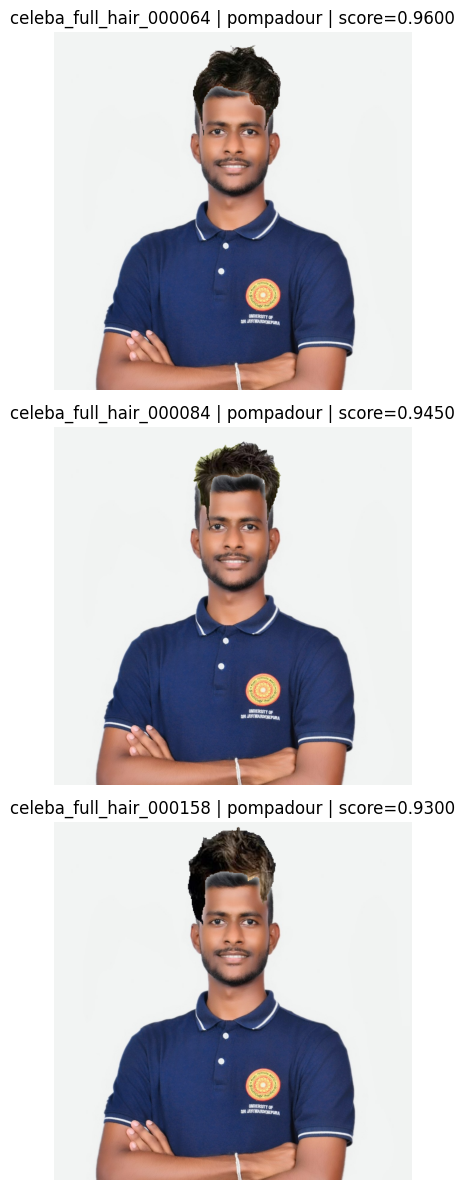

In [10]:
if tryon_rows:
    fig, axes = plt.subplots(len(tryon_rows), 1, figsize=(6, 4 * len(tryon_rows)))
    if len(tryon_rows) == 1:
        axes = [axes]
    for axis, row in zip(axes, tryon_rows):
        with Image.open(row['output_path']) as output_image:
            axis.imshow(output_image.convert('RGB'))
        axis.set_title(f"{row['asset_id']} | {row['style_family']} | score={row['score']:.4f}")
        axis.axis('off')
    plt.tight_layout()
else:
    print('No try-on outputs were created.')